<a href="https://colab.research.google.com/github/Richmiz/brain_tumor_classification/blob/main/Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LeakyReLU, BatchNormalization, Dropout, Dense, Flatten, Input
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt

import os
from google.colab import drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (1910).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (2028).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (1569).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (2069).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (87).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (2).jpg
/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set/Brain Tumor Data Set/Healthy/Not Cancer  (966).jpg
/content/drive/MyDrive/Dataset_OOP/Br

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.5167 - loss: 0.9632 - val_accuracy: 0.9944 - val_loss: 0.2467
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6549 - loss: 0.6564 - val_accuracy: 1.0000 - val_loss: 3.1409e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7269 - loss: 0.5636 - val_accuracy: 1.0000 - val_loss: 6.7856e-08
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7984 - loss: 0.4652 - val_accuracy: 1.0000 - val_loss: 4.0955e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8340 - loss: 0.3875 - val_accuracy: 1.0000 - val_loss: 8.8071e-09
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9157 - loss: 0.3018 - val_accuracy: 1.0000 - val_loss: 1.7783e-20
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9479 - loss: 0.2400 - val_accuracy: 1.0000 - val_loss: 1.2046e-25
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9708 - loss: 0.1811 - val_accuracy: 1.00

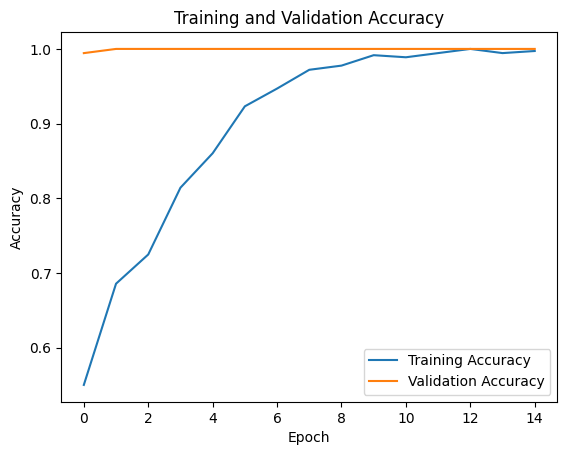

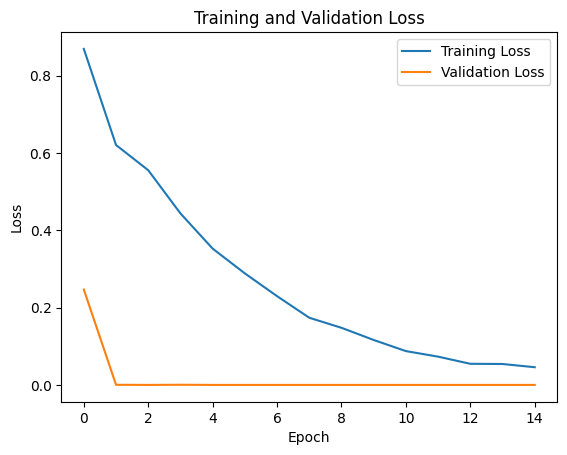

In [ ]:
class ImageClassificationPipeline:
  def __init__(self, dataset_path, model_save_path):
    self.dataset_path = dataset_path
    self.model_save_path = model_save_path
    self.train_generator = None
    self.validation_generator = None
    self.model = None

  def mount_drive(self):
    drive.mount('/content/drive')

  def chek_dataset(self):
    for dirname, _, filenames in os.walk(self.dataset_path):
      for filename in filenames:
        print(os.path.join(dirname, filename))

  def initialize_data_generators(self):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )

    self.train_generator = train_datagen.flow_from_directory(
        self.dataset_path,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary',
        subset='training'
    )

    self.validation_generator = train_datagen.flow_from_directory(
        self.dataset_path,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary',
        subset='validation'
    )

  def define_model(self):
    from tensorflow import keras
    self.model = keras.Sequential([
        Input(shape=(150, 150, 3)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),


        Dense(1, activation='sigmoid')
    ])

    self.model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )

  def train_model(self, epochs=20):
    early_stopping = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    history = self.model.fit(
        self.train_generator,
        validation_data=self.validation_generator,
        epochs=epochs,
        callbacks=[early_stopping]
    )

    return history

  def plot_history(self, history):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

  def save_model(self):
    self.model.save(self.model_save_path)

dataset_path = '/content/drive/MyDrive/Dataset_OOP/Brain_Tumur/Brain Tumor Data Set'
model_save_path = '/content/drive/MyDrive/Dataset_OOP/model.h5'

piepeline = ImageClassificationPipeline(dataset_path, model_save_path)
piepeline.mount_drive()
piepeline.chek_dataset()
piepeline.initialize_data_generators()
piepeline.define_model()
history = piepeline.train_model()
piepeline.plot_history(history)